<a href="https://colab.research.google.com/github/diegosolgtz-pixel/NovaRetail/blob/main/S8_Student_Version_Project_NovaRetail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [ ]:
# Importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

### Cargar Dataset

In [ ]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [ ]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
-
-`edad`
-`nivel_ingreso`
-`visitas_mes`
-`compras_mes`
-`gasto_publicidad_dirigida`
-`satisfaccion`
-`ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna 'ingreso_anual' tiene varios valores en 0 y los números estan persentados como dos enteros con dos decimáles cuando deberian ser miles.


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [ ]:
# Corregir el tipo de dato
df['ingreso_anual'] = df['ingreso_anual'] * 1000

In [ ]:
# Cuántos valores son exactamente 0 en ingreso_anual
print(f"Valores en 0 en ingreso_anual: {(df['ingreso_anual'] == 0).sum()}")
print(f"Porcentaje: {(df['ingreso_anual'] == 0).mean() * 100:.2f}%")

Valores en 0 en ingreso_anual: 4567
Porcentaje: 30.45%


In [ ]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [ ]:
# Estadísticas descriptivas de variables numéricas
print(df[['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 'gasto_publicidad_dirigida', 'satisfaccion','ingreso_anual']].describe())

               edad  nivel_ingreso   visitas_mes   compras_mes  \
count  15000.000000   15000.000000  15000.000000  15000.000000   
mean      38.262400   30019.704782     10.029000      1.206467   
std       11.492378    9833.166305      3.158189      1.105284   
min       18.000000    8000.000000      1.000000      0.000000   
25%       30.000000   23127.097500      8.000000      0.000000   
50%       38.000000   30023.745000     10.000000      1.000000   
75%       46.000000   36768.440000     12.000000      2.000000   
max       75.000000   74790.840000     25.000000      8.000000   

       gasto_publicidad_dirigida  satisfaccion  ingreso_anual  
count               15000.000000  15000.000000   15000.000000  
mean                   20.149301      3.603693   36594.180000  
std                    10.880724      0.685300   34484.888119  
min                     0.000000      1.000000       0.000000  
25%                    12.310000      3.100000       0.000000  
50%                  

✍️ Diagnóstico inicial de variables numéricas

- edad : La distribución es muy equilibrada. La media y la mediana (50%) están en los 38 años, con un rango que va desde los 18 hasta los 75. Es un público adulto joven y maduro bien distribuido.
- nivel_ingreso : Los datos son muy consistentes. El promedio es de 30,019 y el ya que la media y la mediana son casi iguales indica que no hay valores extremos (outliers) que deformen la métrica.
- visitas_mes : Hay actividad constante. El cliente promedio visita la plataforma 10 veces al mes, pero el máximo es 25; existe un grupo de usuarios que entran casi diario.
- compras_mes : El promedio es bajo (1.2 compras), y el 25% de los usuarios (Q1) tiene 0 compras. Esto es relevante porque una buena parte de los visitantes solo observa pero no compra.
- gasto_publicidad_dirigida: La inversión por cliente es moderada, con un promedio de 20.41 y hay un valor minimo e 0 por lo que hay clientes que llegan de forma orgánica sin costo publicitario directo.
- satisfaccion: El promedio es de 3.6, y el 75% de los usuarios califica por encima de 3.1. No parece haber problemas de satisfacción, aunque hay un valor mínimo de 1.0 que merece revisión.
- ingreso_anual : Esta columna tiene muchísima variabilidad (desviación estándar de $34,484). El 25% de los datos son 0.00 lo que confirma  lo observado en compras_mes, hay muchos usuarios registrados que no generaron ingresos este año.


#### Explorar variables binarias

In [ ]:
# Verificar que cada columna tenga únicamente dos valores posibles
print("Valores únicos en miembro_premium:", df['miembro_premium'].unique())
print("Valores únicos en abandono:", df['abandono'].unique())
print("Distribución de Miembro Premium:")
print(df['miembro_premium'].value_counts())
print("\nDistribución de Abandono (Churn):")
print(df['abandono'].value_counts())

Valores únicos en miembro_premium: [0 1]
Valores únicos en abandono: [0 1]
Distribución de Miembro Premium:
0    12911
1     2089
Name: miembro_premium, dtype: int64

Distribución de Abandono (Churn):
0    12739
1     2261
Name: abandono, dtype: int64





Diagnóstico inicial de variables binarias

- `miembro_premium` — Tenemos una cantidad pequeña de miembros premium de aproximadamente un 14%.
- `abandono` — La tasa de abandono es muy pequeña, no llega al 15%,lo cual es buena señal.

#### Explorar variables categóricas

In [ ]:
# Verificar el número de valores únicos por variable categórica
for columna in ['id_cliente', 'tipo_dispositivo', 'region']:
    print(f"{columna}: {df[columna].nunique()} valores únicos")
    print(f"Valores: {df[columna].unique()}")
    print()

id_cliente: 15000 valores únicos
Valores: ['CL-100000' 'CL-100001' 'CL-100002' ... 'CL-114997' 'CL-114998'
 'CL-114999']

tipo_dispositivo: 3 valores únicos
Valores: ['móvil' 'tablet' 'escritorio']

region: 4 valores únicos
Valores: ['norte' 'sur' 'este' 'oeste']



In [ ]:
# Explorar variables categóricas y cómo se distribuyen
print(df[['tipo_dispositivo','region']].describe())
print("Distribución de tipo_dispositivo:")
print(df['tipo_dispositivo'].value_counts())
print("\nDistribución de region:")
print(df['region'].value_counts())

       tipo_dispositivo region
count             15000  15000
unique                3      4
top               móvil  norte
freq               9818   4395
Distribución de tipo_dispositivo:
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

Distribución de region:
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64


Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — Se observa una clara preferencia por el uso de dispositivos móviles (Poco mas del 60% de usuarios), lo que posiciona a este canal como el activo más crítico para las estrategias de conversión.
-  `region` — La base de clientes está bastante equilibrada geográficamente, la región Norte concentra la mayor cantidad de clientes. La brecha respecto a la región Este (la menor) indica una oportunidad de crecimiento regional mediante campañas geolocalizadas.


### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

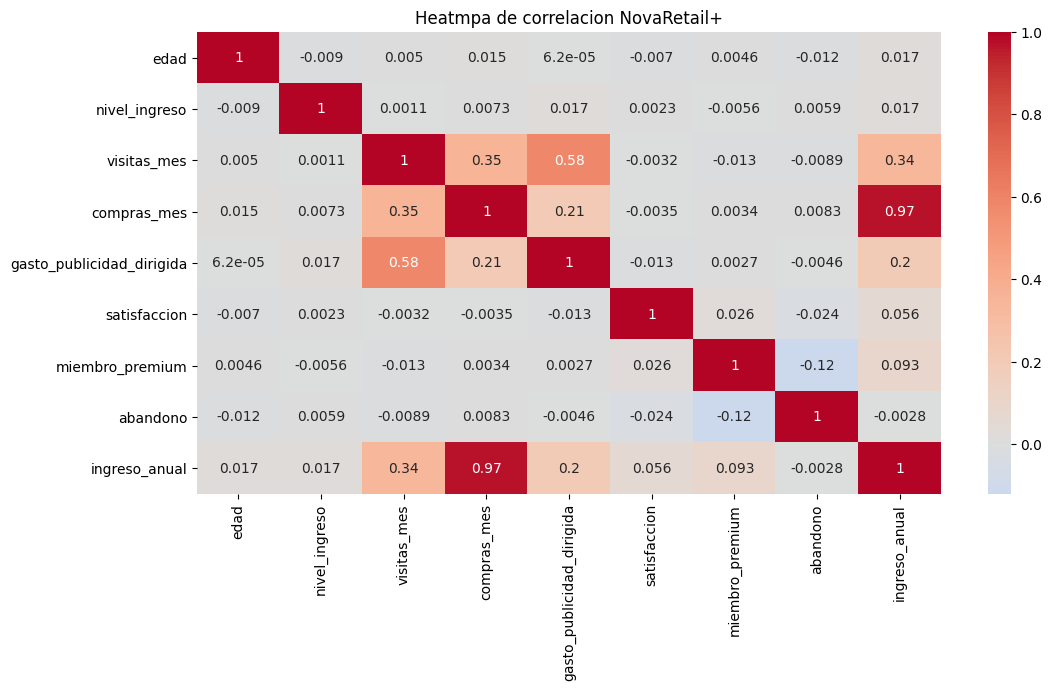

In [ ]:
# Visualizar la matriz de correlación para identificar relaciones
corr= df.corr()
plt.figure( figsize=(12,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Heatmpa de correlacion NovaRetail+")
plt.show()

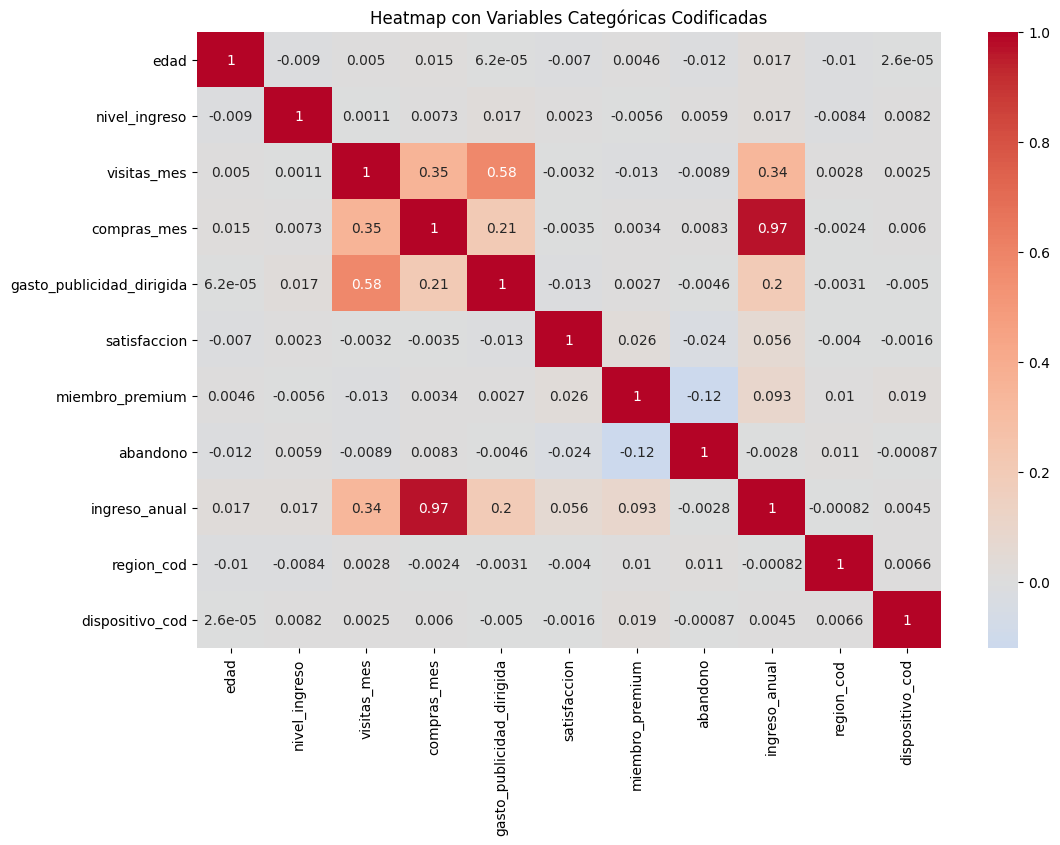

In [ ]:
# copia para no alterar los datos originales de análisis
df_encoded = df.copy()

# Convertir texto a números
df_encoded['region_cod'] = df_encoded['region'].astype('category').cat.codes
df_encoded['dispositivo_cod'] = df_encoded['tipo_dispositivo'].astype('category').cat.codes

# Graficar de nuevo incluyendo las nuevas columnas
plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Heatmap con Variables Categóricas Codificadas")
plt.show()

Observaciones generales (Heatmap)  
- Se observa que la gran mayoría de las variables presentan correlaciones nulas o extremadamente bajas (cercanas a 0), lo que indica que no hay relaciones lineales simples entre la mayoría de los factores del cliente (como edad, nivel de ingreso o satisfacción). No obstante, destacan dos relaciones positivas moderadas: visitas_mes vs gasto_publicidad_dirigida (0.58), sugiriendo que la inversión publicitaria logra atraer tráfico, y visitas_mes vs compras_mes (0.35).

Al integrar las variables categóricas codificadas (region_cod y dispositivo_cod), se confirma visualmente que no existen relaciones lineales significativas entre la geografía o el tipo de dispositivo y el resto de las métricas numéricas.


Observaciones respecto a `ingreso_anual`  
- Presenta una correlación positiva extremadamente alta, casi perfecta, con compras_mes (0.97).

Factores secundarios como visitas_mes (0.34) y gasto_publicidad_dirigida (0.2) muestran asociaciones positivas leves, indicando que el tráfico y el marketing influyen, pero no de forma tan directa como la conversión final.

Es relevante notar la desconexión casi total entre el nivel_ingreso (personal) (0.017) y el ingreso generado a la plataforma, reafirmando que el factor clave no es el poder adquisitivo del cliente, sino su comportamiento transaccional dentro de la tienda.

Las variables de region_cod (-0.00082) y dispositivo_cod (0.0045) no muestran asociación lineal con el ingreso anual, sugiriendo que el gasto es homogéneo entre regiones y dispositivos.


### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - Explica por qué.
  - Dado que la matriz de correlación revela que solo existe una relación lineal fuerte (compras_mes vs ingreso_anual a 0.97), generar scatterplots para el resto de las variables (con coeficientes cercanos a 0) resultaría en nubes de puntos sin patrones visibles ni utilidad analítica. Es más eficiente proceder directamente a analizar la relación fuerte identificada mediante un scatterplot específico

### Scatterplot para pares clave

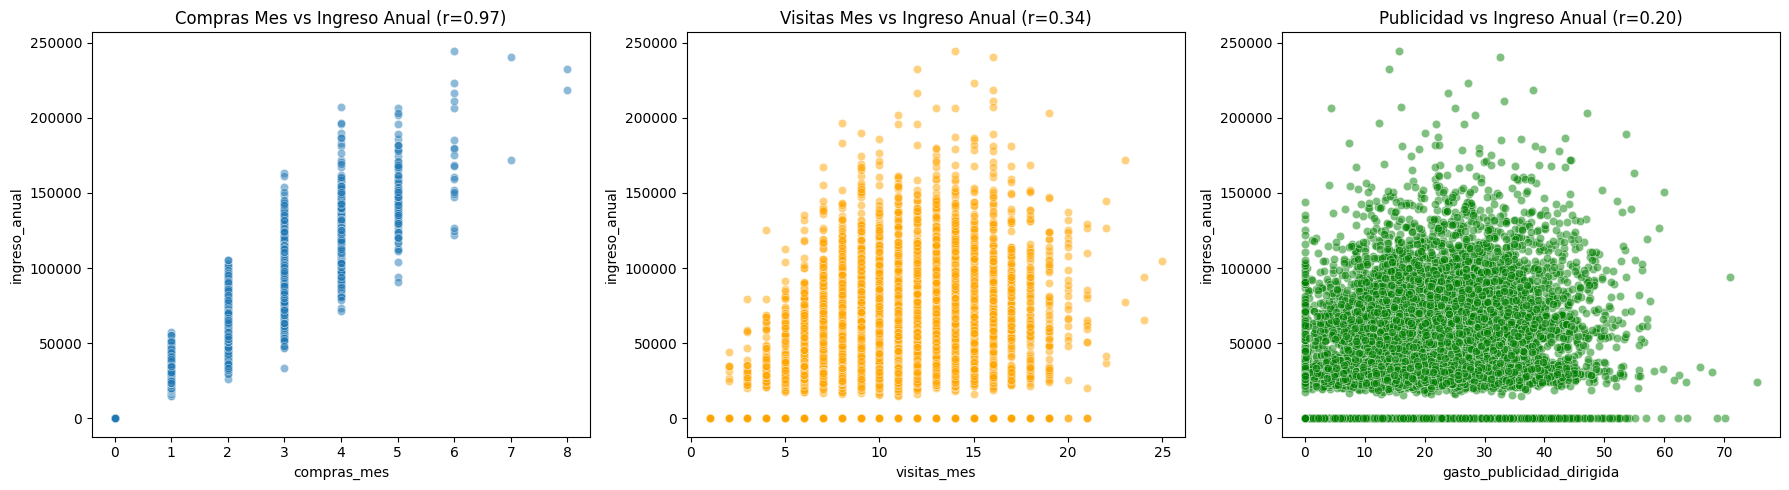

In [ ]:
# Visualizar pares de variables con relaciones moderadas o fuertes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Compras vs Ingreso (Relación más fuerte)
sns.scatterplot(data=df, x='compras_mes', y='ingreso_anual', ax=axes[0], alpha=0.5)
axes[0].set_title('Compras Mes vs Ingreso Anual (r=0.97)')

# 2. Visitas vs Ingreso (Relación Moderada)
sns.scatterplot(data=df, x='visitas_mes', y='ingreso_anual', ax=axes[1], alpha=0.5, color='orange')
axes[1].set_title('Visitas Mes vs Ingreso Anual (r=0.34)')

# 3. Publicidad vs Ingreso (Relación Leve)
sns.scatterplot(data=df, x='gasto_publicidad_dirigida', y='ingreso_anual', ax=axes[2], alpha=0.5, color='green')
axes[2].set_title('Publicidad vs Ingreso Anual (r=0.20)')

plt.tight_layout()
plt.show()

Observaciones iniciales (Scatterplot)

**compras_mes vs Ingreso_anual**
- Dirección positiva muy fuerte.
- La dispersión es muy baja, los puntos forman una línea casi recta hacia arriba.
- Cada compra adicional que hace un cliente al mes sube su nivel de gasto anual de forma casi exacta.

**visitas_mes vs Ingreso_anual**
- Dirección positiva moderada.
- La dispersión es media-alta.
- Entrar a la tienda no garantiza que haya compras. Hay gente que entra 20 veces y gasta poco, y gente que entra 10 veces y gasta mucho. Sin embargo, se nota que los que más gastan suelen estar en el rango de 10 a 20 visitas.
- Hay mucho tráfico pero recordemos que mucha gente solo entra a observar.

**gasto_publicidad_dirigida vs Ingreso_anual**
- Dirección positiva baja.
- La dispersión es muy alta, por eso parece una nube de puntos sin mucha forma.
- Invertir en publicidad ayuda a que el ingreso suba un poco, pero la relación es débil. Hay una línea de puntos en la base ($0 de ingreso) que muestra clientes en los que gastamos mucho en publicidad no compraron nada.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [ ]:
# Calcular correlación entre variables relevantes
print(df['compras_mes'].corr(df['ingreso_anual'], method='pearson'))
print(df['visitas_mes'].corr(df['ingreso_anual'], method='pearson'))
print(df['gasto_publicidad_dirigida'].corr(df['ingreso_anual'], method='pearson'))

0.9671485435708554
0.33714664324987503
0.1974827018234103


In [ ]:
# Calcular correlación entre variables relevantes
print(df['compras_mes'].corr(df['ingreso_anual'], method='spearman'))
print(df['visitas_mes'].corr(df['ingreso_anual'], method='spearman'))
print(df['gasto_publicidad_dirigida'].corr(df['ingreso_anual'], method='spearman'))

0.967482492032673
0.32095369737696483
0.18499874477115502


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves: dirección, magnitud y posible colinealidad.


Observaciones de correlación

**compras_mes vs ingreso_anual**
- Correlación: 0.967 (Pearson) y 0.967 (Spearman).
- Dirección y Magnitud: Dirección positiva con una magnitud muy fuerte (casi perfecta).
- Diagnóstico: Existe una relación lineal directa; a medida que aumentan las compras mensuales, el ingreso anual crece de forma proporcional. Ambos métodos coinciden, lo que confirma este hallazgo.

**visitas_mes vs ingreso_anual**
- Correlación 0.337 (Pearson) y 0.320 (Spearman).
- Dirección y Magnitud: Dirección positiva con una magnitud moderada-débil.
- Diagnóstico: Aunque más visitas tienden a generar más ingresos, la relación no es tan estricta como con las compras. Esto sugiere que el tráfico al sitio es un paso necesario, pero no garantiza la conversión económica.

**gasto_publicidad_dirigida vs ingreso_anual**
- Correlación 0.197 (Pearson) y 0.184 (Spearman).
- Dirección y Magnitud: Dirección positiva con una magnitud débil.
- Diagnóstico: La inversión publicitaria tiene un impacto positivo en el ingreso, pero es el factor menos influyente de los tres analizados. Esto indica que hay otros factores (probablemente la satisfacción o el tipo de producto) que median esta relación.

### Punto-biserial

In [ ]:
# Calcular correlación entre variables relevantes
from scipy.stats import pointbiserialr
print(pointbiserialr(df['miembro_premium'],df['ingreso_anual']))
print(pointbiserialr(df['abandono'],df['ingreso_anual']))

SignificanceResult(statistic=0.0930994396198015, pvalue=3.0943076155242597e-30)
SignificanceResult(statistic=-0.002823934021617144, pvalue=0.7294691719078393)


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), magnitud (alta, media, baja).

Observaciones Punto-biserial

**miembro_premium vs ingreso_anual**
- Relación Dirección positiva con una magnitud baja (0.093).
- Existe una relación positiva estadísticamente significativa (p-value muy cercano a cero), lo que indica que ser un usuario Premium sí tiende a generar un mayor ingreso anual. Sin embargo, la magnitud es baja, lo que sugiere que hay muchos usuarios "normales" que también gastan sumas considerables o que el programa Premium aún tiene mucho margen para incentivar un gasto mucho mayor.

**abandono vs ingreso_anual**
- Relación Dirección negativa con una magnitud nula (-0.0028).
- La correlación es prácticamente cero y el p-value (0.72) es muy alto, lo que significa que no hay evidencia estadística de que el nivel de gasto anual determine si un usuario abandonará la plataforma o no. El abandono parece ser un fenómeno independiente del dinero que el cliente gasta; un cliente de alto valor tiene la misma probabilidad de irse que uno de bajo valor. Esto indica que el problema del abandono podría estar más ligado a la satisfacción o al servicio que al costo de los productos.

### V de Cramér

In [ ]:

# Función para calcular V de Cramér
from scipy.stats import chi2_contingency

def cramers_v(var1, var2):
    tabla1 = pd.crosstab(var1, var2)
    chi2, _, _, _ = chi2_contingency(tabla1)
    n = tabla1.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(tabla1.shape) - 1)))
    return cramers_v
# Para región vs. miembro_premium
resultado1 = cramers_v(df['region'], df['miembro_premium'])

# Para región vs. abandono
resultado2 = cramers_v(df['region'], df['abandono'])


In [ ]:
# Aplicar V de Cramér en variables relevantes
print(f"Cramér's V entre región y miembro premium: {resultado1:.4f}")
print(f"Cramér's V entre región y abandono: {resultado2:.4f}")

Cramér's V entre región y miembro premium: 0.0126
Cramér's V entre región y abandono: 0.0154


**Observaciones V de Cramér**

**región vs miembro_premium**
Se observa una relación extremadamente débil de 0.0126
Esto indica que el programa Premium está distribuido de manera uniforme en todas las regiones. No hay una zona geográfica específica que prefiera o rechace más la suscripción; el interés por ser Premium es independiente de dónde viva el usuario.

**región vs abandono**
Relación de 0.0154, también es extremadamente débil.
El fenómeno del abandono no está ligado a la ubicación geográfica. Esto sugiere que no hay problemas logísticos o de servicio específicos en una sola región que estén causando que los clientes se vayan; el abandono ocurre por igual en el Norte, Sur, Este y Oeste.


## Sección 5 - Interpretación de resultados para el negocio


### Hallazgo 1 —
**Impacto limitado del gasto publicitario en la generación de ingresos**
**Evidencia visual:**  
En el scatterplot de Publicidad vs Ingreso Anual, se observa una nube de puntos con alta dispersión y sin una tendencia lineal clara. Destaca una acumulación densa de puntos en la base del gráfico ($0 de ingreso), lo que indica una cantidad considerable de usuarios que reciben inversión publicitaria sin realizar compras.

**Evidencia numérica:**
La correlación de Pearson es de 0.197, lo que se clasifica como una relación positiva muy débil.

La correlación de Spearman confirma esta tendencia con un valor de 0.184.

El heatmap general muestra que esta variable tiene mayor peso en atraer visitas (0.58) que en generar ingresos finales (0.20).

**Interpretación**  
Existe una asociación leve entre lo que se invierte en publicidad dirigida y el ingreso anual que deja el cliente. Los datos sugieren que la publicidad es efectiva para "llevar al cliente a la puerta" (generar visitas), pero pierde fuerza al momento de asegurar la conversión económica final (realizar una compra).

**No podemos afirmar**  
No podemos asegurar que aumentar el presupuesto publicitario resultará en un incremento proporcional de las ventas, ni que la publicidad actual esté fallando por completo, ya que sí existe una relación positiva, aunque mínima.

**Implicación de negocio**  
La recomendación es auditar la segmentación de la publicidad dirigida. Actualmente, el gasto publicitario parece estar captando "curiosos" en lugar de "compradores". Una optimización hacia audiencias con mayor intención de compra podría mejorar el retorno de inversión (ROI) y fortalecer esa correlación de 0.20 hacia niveles más rentables.

### Hallazgo 2 —
**El comportamiento transaccional predomina sobre el perfil socioeconómico del cliente**

**Evidencia visual:**   
El Heatmap muestra una correlación de 0.017 entre nivel_ingreso e ingreso_anual.

Al observar la matriz de correlación completa, la edad también presenta una asociación nula (0.017) con el gasto final.

**Evidencia numérica:**
El coeficiente de Pearson para nivel_ingreso vs ingreso_anual es prácticamente cero (0.017).

La correlación Punto-Biserial de miembro_premium vs ingreso_anual es baja (0.093), lo que refuerza que incluso el estatus de suscripción tiene menos peso que la actividad pura.

**Interpretación**  
Este es un hallazgo interesante: el nivel de sueldo estimado del cliente o su edad, no dictan cuánto gasta en NovaRetail+. Un cliente con un ingreso personal alto no es necesariamente un cliente de alto valor para nosotros. El valor real del cliente está determinado exclusivamente por su frecuencia de interacción y conversión (compras_mes).

**No podemos afirmar**  
No podemos afirmar que los clientes con ingresos altos no tengan dinero para comprar, sino que actualmente la plataforma no está logrando capturar una mayor parte de su cartera (Share of Wallet) en comparación con clientes de ingresos menores.

**Implicación de negocio**  
Este hallazgo sugiere que nuestra estrategia de segmentación actual basada en demografía (edad/ingreso) puede ser ineficiente.

COmo recomendación podemos movernos de una segmentación demográfica a una segmentación conductual (RFM: Recencia, Frecuencia, Monto).

En lugar de buscar "clientes con dinero",  enfocarnos en "clientes con hábito". Es más rentable incentivar a un usuario recurrente a subir de 1 a 2 compras al mes que intentar atraer a un perfil de altos ingresos que no tiene el hábito de uso de nuestra plataforma.

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ causalidad
- Es fundamental entender que la correlación solo mide si dos variables se mueven juntas, pero no nos dice si una es la causa directa de la otra, ya que podría haber factores externos o una relación de coincidencia que no estamos viendo.
- Por ejemplo: Aunque identificamos que las compras mensuales explican casi todo el ingreso anual, no podemos asegurar que forzar un aumento en las compras (mediante descuentos agresivos, por ejemplo) mantendrá los mismos márgenes de utilidad a largo plazo.
-

### **Próximos pasos**

- [opcion 1]
Probar segmentación adicional
Para profundizar en el hallazgo de que el perfil demográfico no dicta el gasto, se proponen las siguientes rutas de análisis con los datos disponibles:
- Análisis de "Eficiencia de Compra" por Nivel Socioeconómico
Segmentación sugerida: Crear un índice que divida compras_mes entre nivel_ingreso
[Paso 1]
Agrupar los usuarios de nivel_ingreso en niveles: bajo, medio, alto

[Paso 2]
Calcular cuánto compran en promedio al mes y cuánto dinero dejan al año

[Paso 3]
-Crear un gráfico de barras que compare el promedio de compras por segment para comprobar si  el hábito de compra es universal y no depende del nivel socioeconómico.